In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# STEP 1 + STEP 2
# DATASET LOADING & TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from collections import Counter

# ============================================================
# CONFIG
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/POTATODATASET/PLDdatasetLDM"

IMG_SIZE = 256
BATCH_SIZE = 32

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device :", device)

# ============================================================
# TRANSFORM
# ============================================================

transform = T.Compose([

    T.Resize((IMG_SIZE, IMG_SIZE)),

    T.ToTensor(),

    T.Normalize(
        [0.5,0.5,0.5],
        [0.5,0.5,0.5]
    )

])

# ============================================================
# LOAD DATASET
# ============================================================

dataset = ImageFolder(
    DATASET_PATH,
    transform=transform
)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

print("Classes:")
print(dataset.classes)

print("\nClass Mapping:")
print(dataset.class_to_idx)

print("\nTotal Images:")
print(len(dataset))

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

labels = [label for _, label in dataset.samples]

class_counts = Counter(labels)

print("\nClass Distribution:")

for class_name, idx in dataset.class_to_idx.items():

    print(
        f"{class_name:15s} : "
        f"{class_counts[idx]}"
    )

# ============================================================
# TRAIN / VAL / TEST SPLIT
# ============================================================

train_size = int(
    0.70 * len(dataset)
)

val_size = int(
    0.15 * len(dataset)
)

test_size = (
    len(dataset)
    - train_size
    - val_size
)

train_dataset, val_dataset, test_dataset = random_split(

    dataset,

    [train_size, val_size, test_size],

    generator=torch.Generator().manual_seed(42)

)

print("\n" + "="*60)
print("DATA SPLIT")
print("="*60)

print("Train Images :", len(train_dataset))
print("Valid Images :", len(val_dataset))
print("Test Images  :", len(test_dataset))

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

# ============================================================
# VERIFY BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\n" + "="*60)
print("BATCH VERIFICATION")
print("="*60)

print("Image Batch Shape :")
print(images.shape)

print("\nLabel Batch Shape :")
print(labels.shape)

print("\nUnique Labels :")
print(torch.unique(labels))

print("\nDataset Ready For LDM Classification")

print("\n" + "="*60)
print("FINAL SPLIT")
print("="*60)

print(f"Train : {len(train_dataset)}")
print(f"Valid : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Device : cuda

DATASET INFORMATION
Classes:
['EarlyBlight', 'Healthy', 'LateBlight']

Class Mapping:
{'EarlyBlight': 0, 'Healthy': 1, 'LateBlight': 2}

Total Images:
4072

Class Distribution:
EarlyBlight     : 1628
Healthy         : 1020
LateBlight      : 1424

DATA SPLIT
Train Images : 2850
Valid Images : 610
Test Images  : 612

BATCH VERIFICATION
Image Batch Shape :
torch.Size([32, 3, 256, 256])

Label Batch Shape :
torch.Size([32])

Unique Labels :
tensor([0, 1, 2])

Dataset Ready For LDM Classification

FINAL SPLIT
Train : 2850
Valid : 610
Test  : 612


In [ ]:


# ============================================================
# STEP 3
# LOAD PRETRAINED LDM ENCODER (LATENT_DIM = 1024)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# CONFIG
# ============================================================

LATENT_DIM = 1024

ENCODER_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "Potato_LDMClassifierTrainEnhnace_Output/"
    "encoder_best.pth"
)

# ============================================================
# RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, in_ch, out_ch):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_ch,
            out_ch,
            3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(
            out_ch,
            out_ch,
            3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(out_ch)

        self.skip = nn.Identity()

        if in_ch != out_ch:
            self.skip = nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=1
            )

    def forward(self, x):

        identity = self.skip(x)

        out = F.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        out = self.bn2(
            self.conv2(out)
        )

        return F.relu(
            out + identity
        )

# ============================================================
# SELF ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.query = nn.Conv2d(
            channels,
            channels // 8,
            1
        )

        self.key = nn.Conv2d(
            channels,
            channels // 8,
            1
        )

        self.value = nn.Conv2d(
            channels,
            channels,
            1
        )

        self.gamma = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, x):

        b, c, h, w = x.shape

        q = self.query(x).view(
            b,
            -1,
            h * w
        ).permute(0, 2, 1)

        k = self.key(x).view(
            b,
            -1,
            h * w
        )

        attn = torch.softmax(
            torch.bmm(q, k),
            dim=-1
        )

        v = self.value(x).view(
            b,
            c,
            h * w
        )

        out = torch.bmm(
            v,
            attn.permute(0, 2, 1)
        )

        out = out.view(
            b,
            c,
            h,
            w
        )

        return self.gamma * out + x

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):

    def __init__(self, latent_dim=1024):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            ResidualBlock(64,64),

            nn.Conv2d(
                64,
                128,
                4,
                stride=2,
                padding=1
            ),

            ResidualBlock(128,128),

            nn.Conv2d(
                128,
                256,
                4,
                stride=2,
                padding=1
            ),

            ResidualBlock(256,256),

            nn.Conv2d(
                256,
                512,
                4,
                stride=2,
                padding=1
            ),

            ResidualBlock(512,512),

            SelfAttention(512),

            nn.Conv2d(
                512,
                512,
                4,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        self.fc = nn.Linear(
            512 * 8 * 8,
            latent_dim
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        z = self.fc(x)

        return z

# ============================================================
# LOAD ENCODER
# ============================================================

encoder = Encoder(
    latent_dim=LATENT_DIM
)

encoder.load_state_dict(
    torch.load(
        ENCODER_PATH,
        map_location=device
    )
)

encoder = encoder.to(device)

print("\nEncoder Loaded Successfully")

# ============================================================
# FREEZE ENCODER
# ============================================================

for param in encoder.parameters():
    param.requires_grad = False

print("Encoder Frozen")

# ============================================================
# VERIFY OUTPUT SHAPE
# ============================================================

encoder.eval()

with torch.no_grad():

    sample_images, _ = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(device)

    z = encoder(sample_images)

print("\nLatent Feature Shape:")
print(z.shape)

print("\nExpected Shape:")
print(f"({BATCH_SIZE}, 1024)")

print("\nSTEP 3 COMPLETED SUCCESSFULLY")


Encoder Loaded Successfully
Encoder Frozen

Latent Feature Shape:
torch.Size([32, 1024])

Expected Shape:
(32, 1024)

STEP 3 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 4
# BUILD LDM CLASSIFIER
# ============================================================

import torch
import torch.nn as nn

NUM_CLASSES = 3
LATENT_DIM = 1024

# ============================================================
# LDM CLASSIFIER
# ============================================================

class LDMClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Sequential(

            nn.Linear(LATENT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, NUM_CLASSES)

        )

    def forward(self, x):

        z = self.encoder(x)

        out = self.classifier(z)

        return out

# ============================================================
# CREATE MODEL
# ============================================================

model = LDMClassifier().to(device)

print(model)

# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

print("\nLatent Dimension :", LATENT_DIM)

print("\nSTEP 4 COMPLETED")

LDMClassifier(
  (encoder): Encoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (skip): Identity()
      )
      (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): ResidualBlock(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.

In [ ]:
# ============================================================
# STEP 5
# TRAINING SETUP
# ============================================================

from torch import optim

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    model.classifier.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='max',

    factor=0.5,

    patience=5,

    min_lr=1e-6

)

# ============================================================
# TRAINING CONFIG
# ============================================================

EPOCHS = 50

BEST_ACC = 0.0

# ============================================================
# TRAINING HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

# ============================================================
# DISPLAY CONFIG
# ============================================================

print("Loss Function :", criterion)

print("Optimizer :", optimizer.__class__.__name__)

print(
    "Initial Learning Rate :",
    optimizer.param_groups[0]["lr"]
)

print("Epochs :", EPOCHS)

print("Latent Dimension :", LATENT_DIM)

print("\nSTEP 5 COMPLETED")

Loss Function : CrossEntropyLoss()
Optimizer : AdamW
Initial Learning Rate : 0.0001
Epochs : 50
Latent Dimension : 1024

STEP 5 COMPLETED


In [ ]:
# ============================================================
# STEP 6
# TRAINING (FROZEN ENCODER)
# ============================================================

from sklearn.metrics import accuracy_score
from tqdm import tqdm
import torch

best_acc = 0.0

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_classifier_best.pth"
)

for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0

    train_true = []
    train_pred = []

    for imgs, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_true.extend(
            labels.cpu().numpy()
        )

        train_pred.extend(
            preds.cpu().numpy()
        )

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = accuracy_score(
        train_true,
        train_pred
    )

    train_losses.append(
        train_loss
    )

    train_accs.append(
        train_acc
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            preds = outputs.argmax(
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = accuracy_score(
        y_true,
        y_pred
    )

    val_losses.append(
        val_loss
    )

    val_accs.append(
        val_acc
    )

    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step(val_acc)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(

            {

                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_accuracy":
                    best_acc

            },

            MODEL_SAVE_PATH

        )

        print(
            f"\n✅ Best Model Saved "
            f"(Val Accuracy = "
            f"{best_acc:.4f})"
        )

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print(

        f"\nEpoch [{epoch+1}/{EPOCHS}]"

        f" | Train Loss: {train_loss:.4f}"

        f" | Train Acc: {train_acc:.4f}"

        f" | Val Loss: {val_loss:.4f}"

        f" | Val Acc: {val_acc:.4f}"

        f" | LR: {current_lr:.2e}"

    )

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

torch.save(

    {

        "train_losses": train_losses,

        "val_losses": val_losses,

        "train_accs": train_accs,

        "val_accs": val_accs,

        "best_val_accuracy": best_acc

    },

    "/content/drive/MyDrive/POTATODATASET/"
    "training_history.pth"

)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)

print("TRAINING COMPLETED")

print("="*60)

print(
    f"Best Validation Accuracy : "
    f"{best_acc:.4f}"
)

print("\nBest Model Saved At:")

print(MODEL_SAVE_PATH)

Epoch 1/50: 100%|██████████| 90/90 [09:34<00:00,  6.39s/it]



✅ Best Model Saved (Val Accuracy = 0.9951)

Epoch [1/50] | Train Loss: 0.1979 | Train Acc: 0.9674 | Val Loss: 0.0345 | Val Acc: 0.9951 | LR: 1.00e-04


Epoch 2/50: 100%|██████████| 90/90 [00:07<00:00, 12.11it/s]



Epoch [2/50] | Train Loss: 0.0222 | Train Acc: 0.9996 | Val Loss: 0.0300 | Val Acc: 0.9934 | LR: 1.00e-04


Epoch 3/50: 100%|██████████| 90/90 [00:08<00:00, 10.45it/s]


...


Epoch [48/50] | Train Loss: 0.0011 | Train Acc: 1.0000 | Val Loss: 0.0280 | Val Acc: 0.9951 | LR: 1.56e-06


Epoch 49/50: 100%|██████████| 90/90 [00:06<00:00, 13.15it/s]



Epoch [49/50] | Train Loss: 0.0102 | Train Acc: 0.9996 | Val Loss: 0.0253 | Val Acc: 0.9967 | LR: 1.00e-06


Epoch 50/50: 100%|██████████| 90/90 [00:06<00:00, 13.89it/s]



Epoch [50/50] | Train Loss: 0.0056 | Train Acc: 0.9996 | Val Loss: 0.0220 | Val Acc: 0.9967 | LR: 1.00e-06

TRAINING COMPLETED
Best Validation Accuracy : 0.9967

Best Model Saved At:
/content/drive/MyDrive/POTATODATASET/EC_LDM_classifier_best.pth


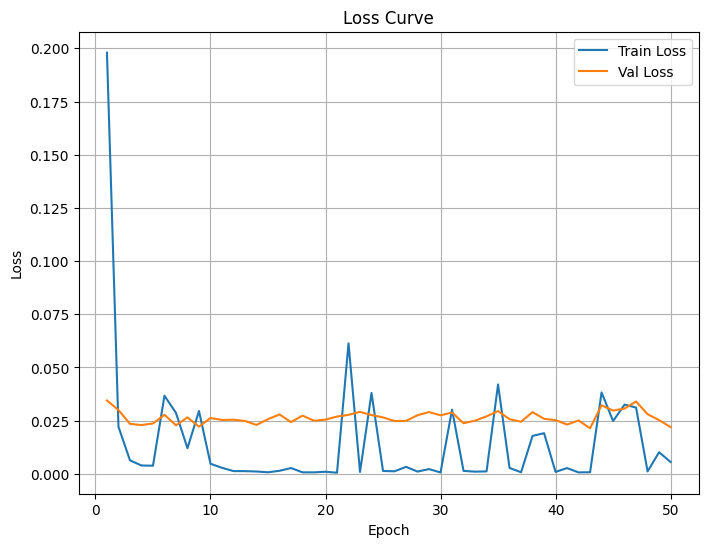

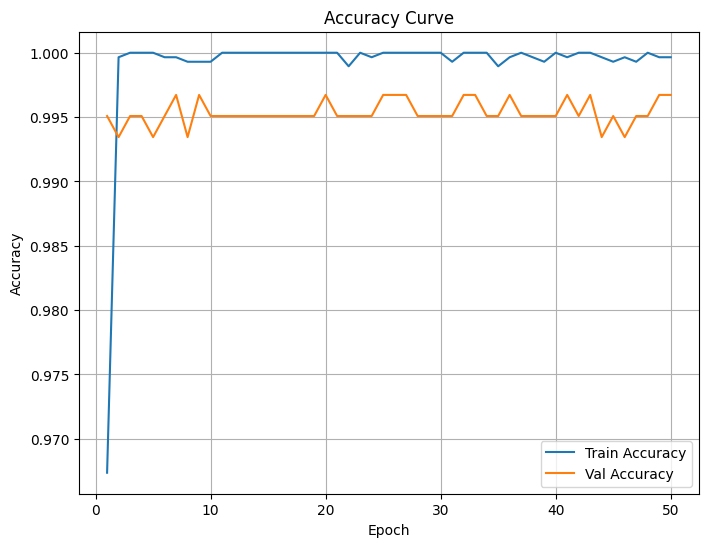

In [ ]:
import torch
import matplotlib.pyplot as plt

history = torch.load(
    "/content/drive/MyDrive/POTATODATASET/training_history.pth"
)

train_losses = history["train_losses"]
val_losses   = history["val_losses"]

train_accs   = history["train_accs"]
val_accs     = history["val_accs"]

epochs = range(1, len(train_losses)+1)

# Loss Graph
plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy Graph
plt.figure(figsize=(8,6))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

BEST MODEL LOADED

TEST PERFORMANCE
Accuracy  : 0.9869
Precision : 0.9870
Recall    : 0.9869
F1 Score  : 0.9869
ROC-AUC   : 0.9998


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 EarlyBlight     0.9876    0.9835    0.9856       243
     Healthy     0.9815    0.9938    0.9876       160
  LateBlight     0.9904    0.9856    0.9880       209

    accuracy                         0.9869       612
   macro avg     0.9865    0.9876    0.9871       612
weighted avg     0.9870    0.9869    0.9869       612



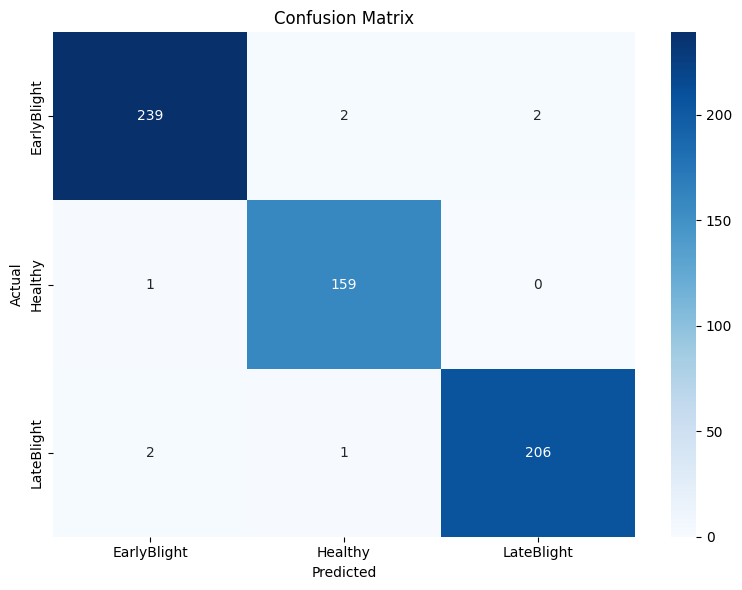

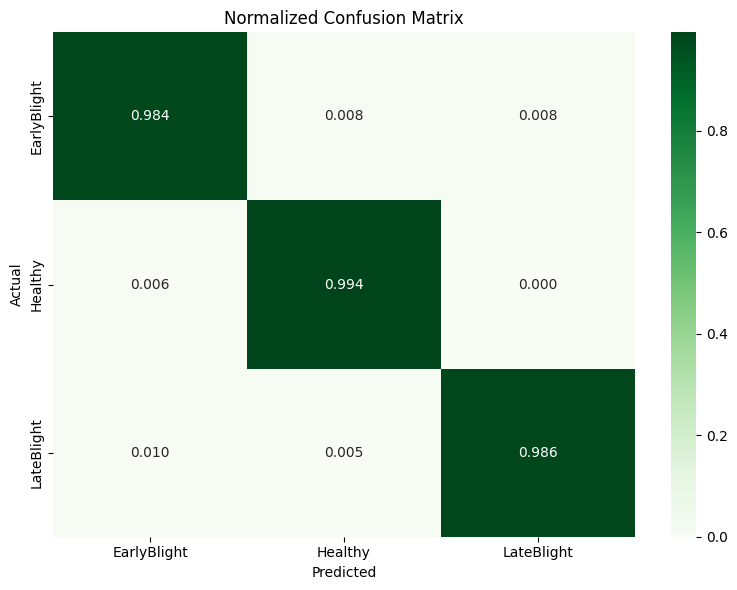

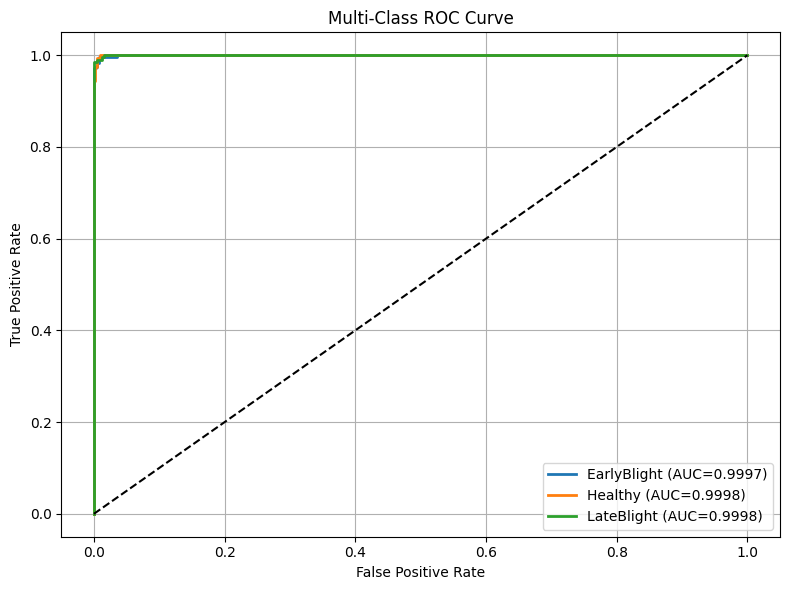


CLASS-WISE ROC-AUC
EarlyBlight         : 0.9997
Healthy             : 0.9998
LateBlight          : 0.9998

Evaluation Completed Successfully!


In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Classification Report + Confusion Matrix + ROC Curve
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# ============================================================
# LOAD BEST MODEL
# ============================================================
MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_classifier_best.pth"
)

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("="*70)
print("BEST MODEL LOADED")
print("="*70)

# ============================================================
# TEST PREDICTION
# ============================================================

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_probs.extend(
            probs.cpu().numpy()
        )

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# ============================================================
# OVERALL METRICS
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

auc_weighted = roc_auc_score(
    y_true,
    y_probs,
    multi_class="ovr",
    average="weighted"
)

print("\n" + "="*70)
print("TEST PERFORMANCE")
print("="*70)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc_weighted:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

class_names = test_dataset.dataset.classes

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\n")
print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(report)

with open(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_classification_report.txt",
    "w"
) as f:
    f.write(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_confusion_matrix.png",
    dpi=300
)

plt.show()

# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_normalized_confusion_matrix.png",
    dpi=300
)

plt.show()

# ============================================================
# ROC CURVES
# ============================================================

n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# ============================================================
# ROC PLOT
# ============================================================

plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{class_names[i]} (AUC={roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_ROC_curve.png",
    dpi=300
)

plt.show()

# ============================================================
# CLASS-WISE AUC
# ============================================================

print("\n" + "="*70)
print("CLASS-WISE ROC-AUC")
print("="*70)

for i in range(n_classes):

    print(
        f"{class_names[i]:<20}: {roc_auc[i]:.4f}"
    )

# ============================================================
# SAVE METRICS CSV
# ============================================================

metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        acc,
        precision,
        recall,
        f1,
        auc_weighted
    ]
})

metrics_df.to_csv(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_metrics.csv",
    index=False
)

print("\nEvaluation Completed Successfully!")

In [ ]:
# ============================================================
# INSPECT SAVED EC-LDM CHECKPOINT
# ============================================================

import torch

MODEL_PATH = "/content/drive/MyDrive/POTATODATASET/EC_LDM_classifier_best.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print("="*70)
print("CHECKPOINT TYPE")
print("="*70)

print(type(checkpoint))

print("\n" + "="*70)
print("CHECKPOINT KEYS")
print("="*70)

if isinstance(checkpoint, dict):

    for k in checkpoint.keys():
        print(k)

    if "model_state_dict" in checkpoint:

        print("\n" + "="*70)
        print("MODEL LAYERS")
        print("="*70)

        state_dict = checkpoint["model_state_dict"]

        for i, (name, param) in enumerate(state_dict.items()):

            print(
                f"{name:<60} {list(param.shape)}"
            )

            if i >= 50:
                break

else:

    print("Checkpoint is not a dictionary.")

print("\nDone.")

CHECKPOINT TYPE
<class 'dict'>

CHECKPOINT KEYS
epoch
model_state_dict
optimizer_state_dict
best_accuracy

MODEL LAYERS
encoder.features.0.weight                                    [64, 3, 4, 4]
encoder.features.0.bias                                      [64]
encoder.features.2.conv1.weight                              [64, 64, 3, 3]
encoder.features.2.conv1.bias                                [64]
encoder.features.2.bn1.weight                                [64]
encoder.features.2.bn1.bias                                  [64]
encoder.features.2.bn1.running_mean                          [64]
encoder.features.2.bn1.running_var                           [64]
encoder.features.2.bn1.num_batches_tracked                   []
encoder.features.2.conv2.weight                              [64, 64, 3, 3]
encoder.features.2.conv2.bias                                [64]
encoder.features.2.bn2.weight                                [64]
encoder.features.2.bn2.bias                                  

In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION CELL
# Enhanced Class-Conditioned LDM
# ============================================================

import torch
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD BEST MODEL
# ============================================================
import torch

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)
MODEL_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_classifier_best.pth"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(
        checkpoint
    )

model.eval()

print("="*70)
print("BEST EC-LDM MODEL LOADED")
print("="*70)

# ============================================================
# TEST EVALUATION
# ============================================================

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(dim=1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_probs.extend(
            probs.cpu().numpy()
        )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

y_true = np.array(y_true)

y_pred = np.array(y_pred)

y_probs = np.array(y_probs)

# ============================================================
# PERFORMANCE METRICS
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro"
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# ============================================================
# ROC AUC
# ============================================================

try:

    auc_score = roc_auc_score(

        y_true,

        y_probs,

        multi_class="ovr",

        average="weighted"

    )

except:

    auc_score = 0.0

# ============================================================
# RESULTS
# ============================================================

print("\n" + "="*70)
print("EC-LDM TEST PERFORMANCE")
print("="*70)

print(f"Accuracy              : {acc:.4f}")

print(f"Precision (Macro)     : {precision_macro:.4f}")
print(f"Precision (Weighted)  : {precision_weighted:.4f}")

print(f"Recall (Macro)        : {recall_macro:.4f}")
print(f"Recall (Weighted)     : {recall_weighted:.4f}")

print(f"F1 Score (Macro)      : {f1_macro:.4f}")
print(f"F1 Score (Weighted)   : {f1_weighted:.4f}")

print(f"ROC-AUC Score         : {auc_score:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

report_text = classification_report(

    y_true,

    y_pred,

    target_names=test_dataset.dataset.classes,

    digits=4

)

print(report_text)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=test_dataset.dataset.classes,

    yticklabels=test_dataset.dataset.classes

)

plt.title(
    "EC-LDM Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=True,

    fmt=".2f",

    cmap="Greens",

    xticklabels=test_dataset.dataset.classes,

    yticklabels=test_dataset.dataset.classes

)

plt.title(
    "EC-LDM Normalized Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_normalized_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ============================================================
# PER-CLASS ACCURACY
# ============================================================

print("\n" + "="*70)
print("PER-CLASS ACCURACY")
print("="*70)

for i, cls in enumerate(
    test_dataset.dataset.classes
):

    class_acc = (
        cm[i, i] /
        cm[i].sum()
    ) * 100

    print(
        f"{cls:<20}: "
        f"{class_acc:.2f}%"
    )

# ============================================================
# SAVE RESULTS
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision Macro",
        "Precision Weighted",

        "Recall Macro",
        "Recall Weighted",

        "F1 Macro",
        "F1 Weighted",

        "ROC-AUC"

    ],

    "Value": [

        acc,

        precision_macro,
        precision_weighted,

        recall_macro,
        recall_weighted,

        f1_macro,
        f1_weighted,

        auc_score

    ]

})

metrics_df.to_csv(

    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_metrics.csv",

    index=False

)

torch.save(

    {

        "accuracy": acc,

        "precision_macro": precision_macro,

        "precision_weighted": precision_weighted,

        "recall_macro": recall_macro,

        "recall_weighted": recall_weighted,

        "f1_macro": f1_macro,

        "f1_weighted": f1_weighted,

        "roc_auc": auc_score,

        "confusion_matrix": cm

    },

    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_test_results.pth"

)

print("\n" + "="*70)
print("TEST EVALUATION COMPLETED")
print("="*70)

print(f"Final Test Accuracy : {acc:.4f}")
print(f"Final Test F1 Score : {f1_weighted:.4f}")
print(f"Final ROC-AUC       : {auc_score:.4f}")

# ============================================================
# MULTI-CLASS ROC CURVE
# ============================================================

n_classes = len(test_dataset.dataset.classes)

# Binarize labels
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

# ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_probs.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# ============================================================
# PLOT ROC CURVES
# ============================================================

plt.figure(figsize=(8,6))

for i, class_name in enumerate(
    test_dataset.dataset.classes
):

    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    lw=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (EC-LDM)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/POTATODATASET/EC_LDM_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PRINT CLASS-WISE AUC
# ============================================================

print("\n" + "="*70)
print("CLASS-WISE ROC-AUC")
print("="*70)

for i, class_name in enumerate(
    test_dataset.dataset.classes
):

    print(
        f"{class_name:<20}: "
        f"{roc_auc[i]:.4f}"
    )

print(
    f"\nMicro Average AUC : "
    f"{roc_auc['micro']:.4f}"
)

Using Device: cuda


NameError: name 'model' is not defined

In [ ]:
# ============================================================
# FINAL TEST EVALUATION
# PROPOSED FINE-TUNED 1024-D EC-LDM
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD BEST MODEL
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_classifier_best.pth"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(
        checkpoint
    )

model.eval()

print("Best EC-LDM Model Loaded")

# ============================================================
# TEST EVALUATION
# ============================================================

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(dim=1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs.cpu().numpy()
        )

# ============================================================
# CONVERT
# ============================================================

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

class_names = test_dataset.dataset.classes

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# ============================================================
# MULTI-CLASS ROC-AUC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

auc_score = roc_auc_score(

    y_true,

    y_prob,

    multi_class="ovr",

    average="weighted"

)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "="*70)
print("EC-LDM TEST PERFORMANCE")
print("="*70)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc_score:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        digits=4

    )

)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.title(
    "EC-LDM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8,6))

class_auc = []

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_class = auc(
        fpr,
        tpr
    )

    class_auc.append(
        roc_auc_class
    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=(
            f"{class_names[i]} "
            f"(AUC={roc_auc_class:.4f})"
        )

    )

plt.plot(
    [0,1],
    [0,1],
    'k--',
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve of Proposed EC-LDM"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ============================================================
# CLASS-WISE AUC
# ============================================================

print("\n" + "="*70)
print("CLASS-WISE ROC-AUC")
print("="*70)

for cls, auc_val in zip(
    class_names,
    class_auc
):

    print(
        f"{cls:<15}: "
        f"{auc_val:.4f}"
    )

print("\n" + "="*70)

print(
    f"Weighted ROC-AUC : "
    f"{auc_score:.4f}"
)

print("="*70)

print("\nEvaluation Completed Successfully")

NameError: name 'device' is not defined

In [ ]:
print(type(test_dataset))
print(type(test_dataset.dataset))
print(test_dataset.dataset.classes)

<class 'torch.utils.data.dataset.Subset'>
<class 'torchvision.datasets.folder.ImageFolder'>
['EarlyBlight', 'Healthy', 'LateBlight']


In [ ]:
# ============================================================
# CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------

acc = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("="*60)
print("OVERALL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=dataset.classes,

        digits=4

    )

)

# ------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=dataset.classes,

    yticklabels=dataset.classes

)

plt.title(
    "LDM Classifier Confusion Matrix"
)

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.show()

NameError: name 'y_true' is not defined

In [ ]:
# FINE TUNE LDM
# ============================================================
# EXPERIMENT B
# UNFREEZE ENCODER
# ============================================================

for param in encoder.parameters():
    param.requires_grad = True

print("Encoder Unfrozen")

# Verify
trainable_params = sum(
    p.numel()
    for p in encoder.parameters()
    if p.requires_grad
)

print("Trainable Encoder Parameters:", trainable_params)

Encoder Unfrozen
Trainable Encoder Parameters: 47107777


In [ ]:
# ============================================================
# STEP 5
# FINE-TUNING SETUP
# ============================================================

import torch.optim as optim
import torch.nn as nn

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# Fine-tune Encoder + Classifier
# ============================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=1e-5,

    weight_decay=1e-4

)

# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='max',

    factor=0.5,

    patience=5,

    min_lr=1e-7

)

# ============================================================
# TRAINING CONFIG
# ============================================================

EPOCHS = 100

BEST_ACC = 0.0

# ============================================================
# TRAINING HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

# ============================================================
# PARAMETER SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ============================================================
# DISPLAY CONFIG
# ============================================================

print("=" * 60)
print("FINE-TUNING CONFIGURATION")
print("=" * 60)

print("Model                : Enhanced CC-LDM Classifier")

print("Latent Dimension     :", LATENT_DIM)

print("Optimizer            : AdamW")

print(
    "Learning Rate        :",
    optimizer.param_groups[0]["lr"]
)

print("Weight Decay         : 1e-4")

print("Epochs               :", EPOCHS)

print("Scheduler            : ReduceLROnPlateau")

print("Total Parameters     :", total_params)

print("Trainable Parameters :", trainable_params)

print("\nEncoder + Classifier will be trained")

print("\nSTEP 5 COMPLETED")

FINE-TUNING CONFIGURATION
Model                : Enhanced CC-LDM Classifier
Latent Dimension     : 1024
Optimizer            : AdamW
Learning Rate        : 1e-05
Weight Decay         : 1e-4
Epochs               : 100
Scheduler            : ReduceLROnPlateau
Total Parameters     : 47765700
Trainable Parameters : 47765700

Encoder + Classifier will be trained

STEP 5 COMPLETED


In [ ]:
# ============================================================
# EC-LDM FINE-TUNING (ENHANCED VERSION)
# ============================================================

import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from torch.cuda.amp import (
    autocast,
    GradScaler
)

# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ------------------------------------------------------------
# DIFFERENTIAL LEARNING RATE
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(

    [

        {
            "params": model.encoder.parameters(),
            "lr": 1e-5
        },

        {
            "params": model.classifier.parameters(),
            "lr": 1e-4
        }

    ],

    weight_decay=1e-4

)

# ------------------------------------------------------------
# LR SCHEDULER
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=5,

    min_lr=1e-7

)

# ------------------------------------------------------------
# MIXED PRECISION
# ------------------------------------------------------------

scaler = GradScaler()

# ------------------------------------------------------------
# SAVE PATHS
# ------------------------------------------------------------

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_finetuned_best.pth"
)

HISTORY_SAVE_PATH = (
    "/content/drive/MyDrive/POTATODATASET/"
    "EC_LDM_history.pth"
)

# ------------------------------------------------------------
# TRACKERS
# ------------------------------------------------------------

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0.0
best_epoch = 0

print("=" * 70)
print("STARTING EC-LDM FINE-TUNING")
print("=" * 70)

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0

    train_true = []
    train_pred = []

    for imgs, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(imgs)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_true.extend(
            labels.cpu().numpy()
        )

        train_pred.extend(
            preds.cpu().numpy()
        )

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = accuracy_score(
        train_true,
        train_pred
    )

    train_losses.append(
        train_loss
    )

    train_accs.append(
        train_acc
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    val_losses.append(
        val_loss
    )

    val_accs.append(
        val_acc
    )

    # ========================================================
    # LR UPDATE
    # ========================================================

    scheduler.step(val_acc)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_acc:

        best_acc = val_acc

        best_epoch = epoch + 1

        torch.save(

            {

                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_accuracy":
                    best_acc

            },

            MODEL_SAVE_PATH

        )

        print(
            f"\n✅ Best Model Saved "
            f"(Val Acc = {best_acc:.4f})"
        )

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print(

        f"\nEpoch [{epoch+1}/{EPOCHS}]"

        f" | Train Loss: {train_loss:.4f}"

        f" | Train Acc: {train_acc:.4f}"

        f" | Val Loss: {val_loss:.4f}"

        f" | Val Acc: {val_acc:.4f}"

        f" | F1: {f1:.4f}"

        f" | LR: {current_lr:.2e}"

    )

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

torch.save(

    {

        "train_losses": train_losses,

        "val_losses": val_losses,

        "train_accs": train_accs,

        "val_accs": val_accs,

        "best_epoch": best_epoch,

        "best_val_accuracy": best_acc

    },

    HISTORY_SAVE_PATH

)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)

print("EC-LDM FINE-TUNING COMPLETED")

print("=" * 70)

print(
    f"Best Epoch : {best_epoch}"
)

print(
    f"Best Validation Accuracy : {best_acc:.4f}"
)

print(
    f"\nBest Model Saved At:\n{MODEL_SAVE_PATH}"
)

/tmp/ipykernel_3528/46450625.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


STARTING EC-LDM FINE-TUNING


Epoch 1/100:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_3528/46450625.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/100: 100%|██████████| 90/90 [00:17<00:00,  5.28it/s]



✅ Best Model Saved (Val Acc = 0.9967)

Epoch [1/100] | Train Loss: 0.3459 | Train Acc: 1.0000 | Val Loss: 0.3144 | Val Acc: 0.9967 | F1: 0.9967 | LR: 1.00e-05


Epoch 2/100:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_3528/46450625.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/100: 100%|██████████| 90/90 [00:30<00:00,  2.93it/s]


...


Epoch [11/100] | Train Loss: 0.3079 | Train Acc: 0.9996 | Val Loss: 0.3071 | Val Acc: 0.9951 | F1: 0.9951 | LR: 5.00e-06


Epoch 12/100:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_3528/46450625.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 12/100: 100%|██████████| 90/90 [00:15<00:00,  5.66it/s]



Epoch [12/100] | Train Loss: 0.2995 | Train Acc: 1.0000 | Val Loss: 0.3040 | Val Acc: 0.9951 | F1: 0.9951 | LR: 5.00e-06


Epoch 13/100:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_3528/46450625.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 13/100:  64%|██████▍   | 58/90 [00:10<00:05,  5.65it/s]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# FINAL TEST EVALUATION
# EXPERIMENT B (FINE-TUNED LDM)
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(

    torch.load(

        "/content/drive/MyDrive/POTATODATASET/LDM_finetuned_best.pth",

        map_location=device

    )

)

model.eval()

print("Best Fine-Tuned Model Loaded")

# ============================================================
# TEST EVALUATION
# ============================================================

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        preds = outputs.argmax(dim=1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs.cpu().numpy()
        )

# ============================================================
# CONVERT
# ============================================================

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================================
# METRICS
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# ============================================================
# MULTI-CLASS AUC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2]
)

auc_score = roc_auc_score(

    y_true_bin,

    y_prob,

    multi_class="ovr"

)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc_score:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=dataset.classes,

        digits=4

    )

)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=dataset.classes,

    yticklabels=dataset.classes

)

plt.title(
    "Test Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8,6))

for i in range(len(dataset.classes)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,

        tpr,

        label=f"{dataset.classes[i]} (AUC={roc_auc:.3f})"

    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves"
)

plt.legend()

plt.grid()

plt.show()

print("\nEvaluation Completed Successfully")

RuntimeError: Error(s) in loading state_dict for LDMClassifier:
	Missing key(s) in state_dict: "classifier.1.weight", "classifier.1.bias", "classifier.1.running_mean", "classifier.1.running_var", "classifier.4.weight", "classifier.4.bias", "classifier.7.weight", "classifier.7.bias". 
	Unexpected key(s) in state_dict: "classifier.3.weight", "classifier.3.bias", "classifier.6.weight", "classifier.6.bias". 
	size mismatch for encoder.fc.weight: copying a param with shape torch.Size([512, 32768]) from checkpoint, the shape in current model is torch.Size([1024, 32768]).
	size mismatch for encoder.fc.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([1024]).
	size mismatch for classifier.0.weight: copying a param with shape torch.Size([256, 512]) from checkpoint, the shape in current model is torch.Size([512, 1024]).
	size mismatch for classifier.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in curre

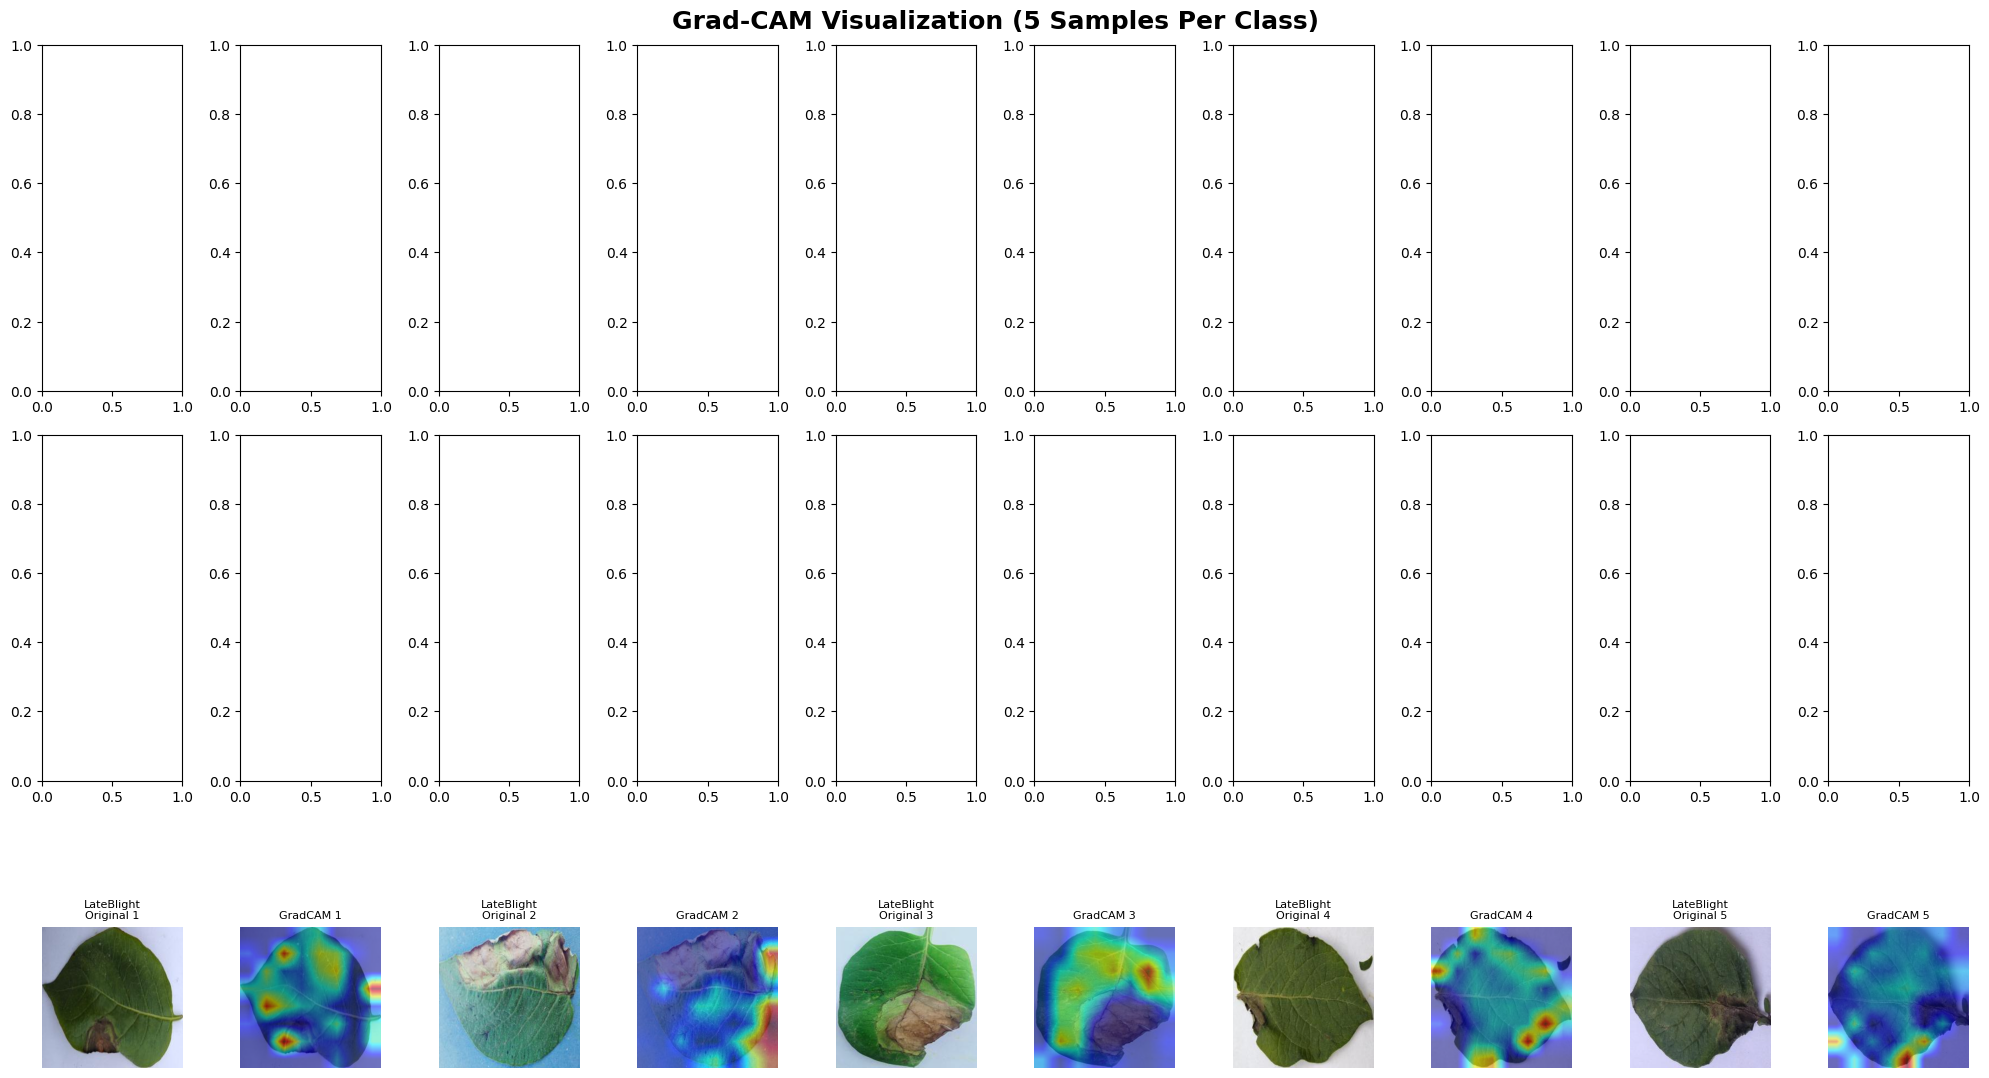


✅ Displayed 5 Grad-CAM samples for each class


In [ ]:
# ============================================================
# FIND 5 CORRECT SAMPLES FROM EACH CLASS
# ============================================================

NUM_SAMPLES_PER_CLASS = 5

samples = {
    cls_id: []
    for cls_id in range(len(dataset.classes))
}

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):

            true_class = labels[i].item()
            pred_class = preds[i].item()

            if true_class == pred_class:

                if len(samples[true_class]) < NUM_SAMPLES_PER_CLASS:

                    samples[true_class].append(
                        (
                            imgs[i].cpu(),
                            pred_class
                        )
                    )

        # Stop when all classes have 5 samples
        done = all(
            len(samples[c]) >= NUM_SAMPLES_PER_CLASS
            for c in samples
        )

        if done:
            break

# ============================================================
# PLOT 5 GRAD-CAM SAMPLES PER CLASS
# ============================================================

num_classes = len(dataset.classes)

fig, axes = plt.subplots(
    num_classes,
    NUM_SAMPLES_PER_CLASS * 2,
    figsize=(20, 4 * num_classes)
)

if num_classes == 1:
    axes = np.expand_dims(axes, axis=0)

for row, class_id in enumerate(samples.keys()):

    for sample_idx, (img_tensor, pred_class) in enumerate(samples[class_id]):

        input_tensor = img_tensor.unsqueeze(0).to(device)

        targets = [
            ClassifierOutputTarget(pred_class)
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        rgb_img = (
            img_tensor
            .permute(1, 2, 0)
            .numpy()
        )

        rgb_img = (
            rgb_img - rgb_img.min()
        ) / (
            rgb_img.max() - rgb_img.min() + 1e-8
        )

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )

        # ----------------------------------------------------
        # ORIGINAL IMAGE
        # ----------------------------------------------------

        col_orig = sample_idx * 2

        axes[row, col_orig].imshow(rgb_img)

        axes[row, col_orig].set_title(
            f"{dataset.classes[class_id]}\nOriginal {sample_idx+1}",
            fontsize=8
        )

        axes[row, col_orig].axis("off")

        # ----------------------------------------------------
        # GRAD-CAM IMAGE
        # ----------------------------------------------------

        col_cam = sample_idx * 2 + 1

        axes[row, col_cam].imshow(cam_image)

        axes[row, col_cam].set_title(
            f"GradCAM {sample_idx+1}",
            fontsize=8
        )

        axes[row, col_cam].axis("off")

plt.suptitle(
    "Grad-CAM Visualization (5 Samples Per Class)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print(
    f"\n✅ Displayed {NUM_SAMPLES_PER_CLASS} Grad-CAM samples for each class"
)

In [ ]:
print(model.encoder)

Encoder(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Identity()
    )
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ResidualBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Iden


Collected Samples:
EarlyBlight -> 0
Healthy -> 0
LateBlight -> 5


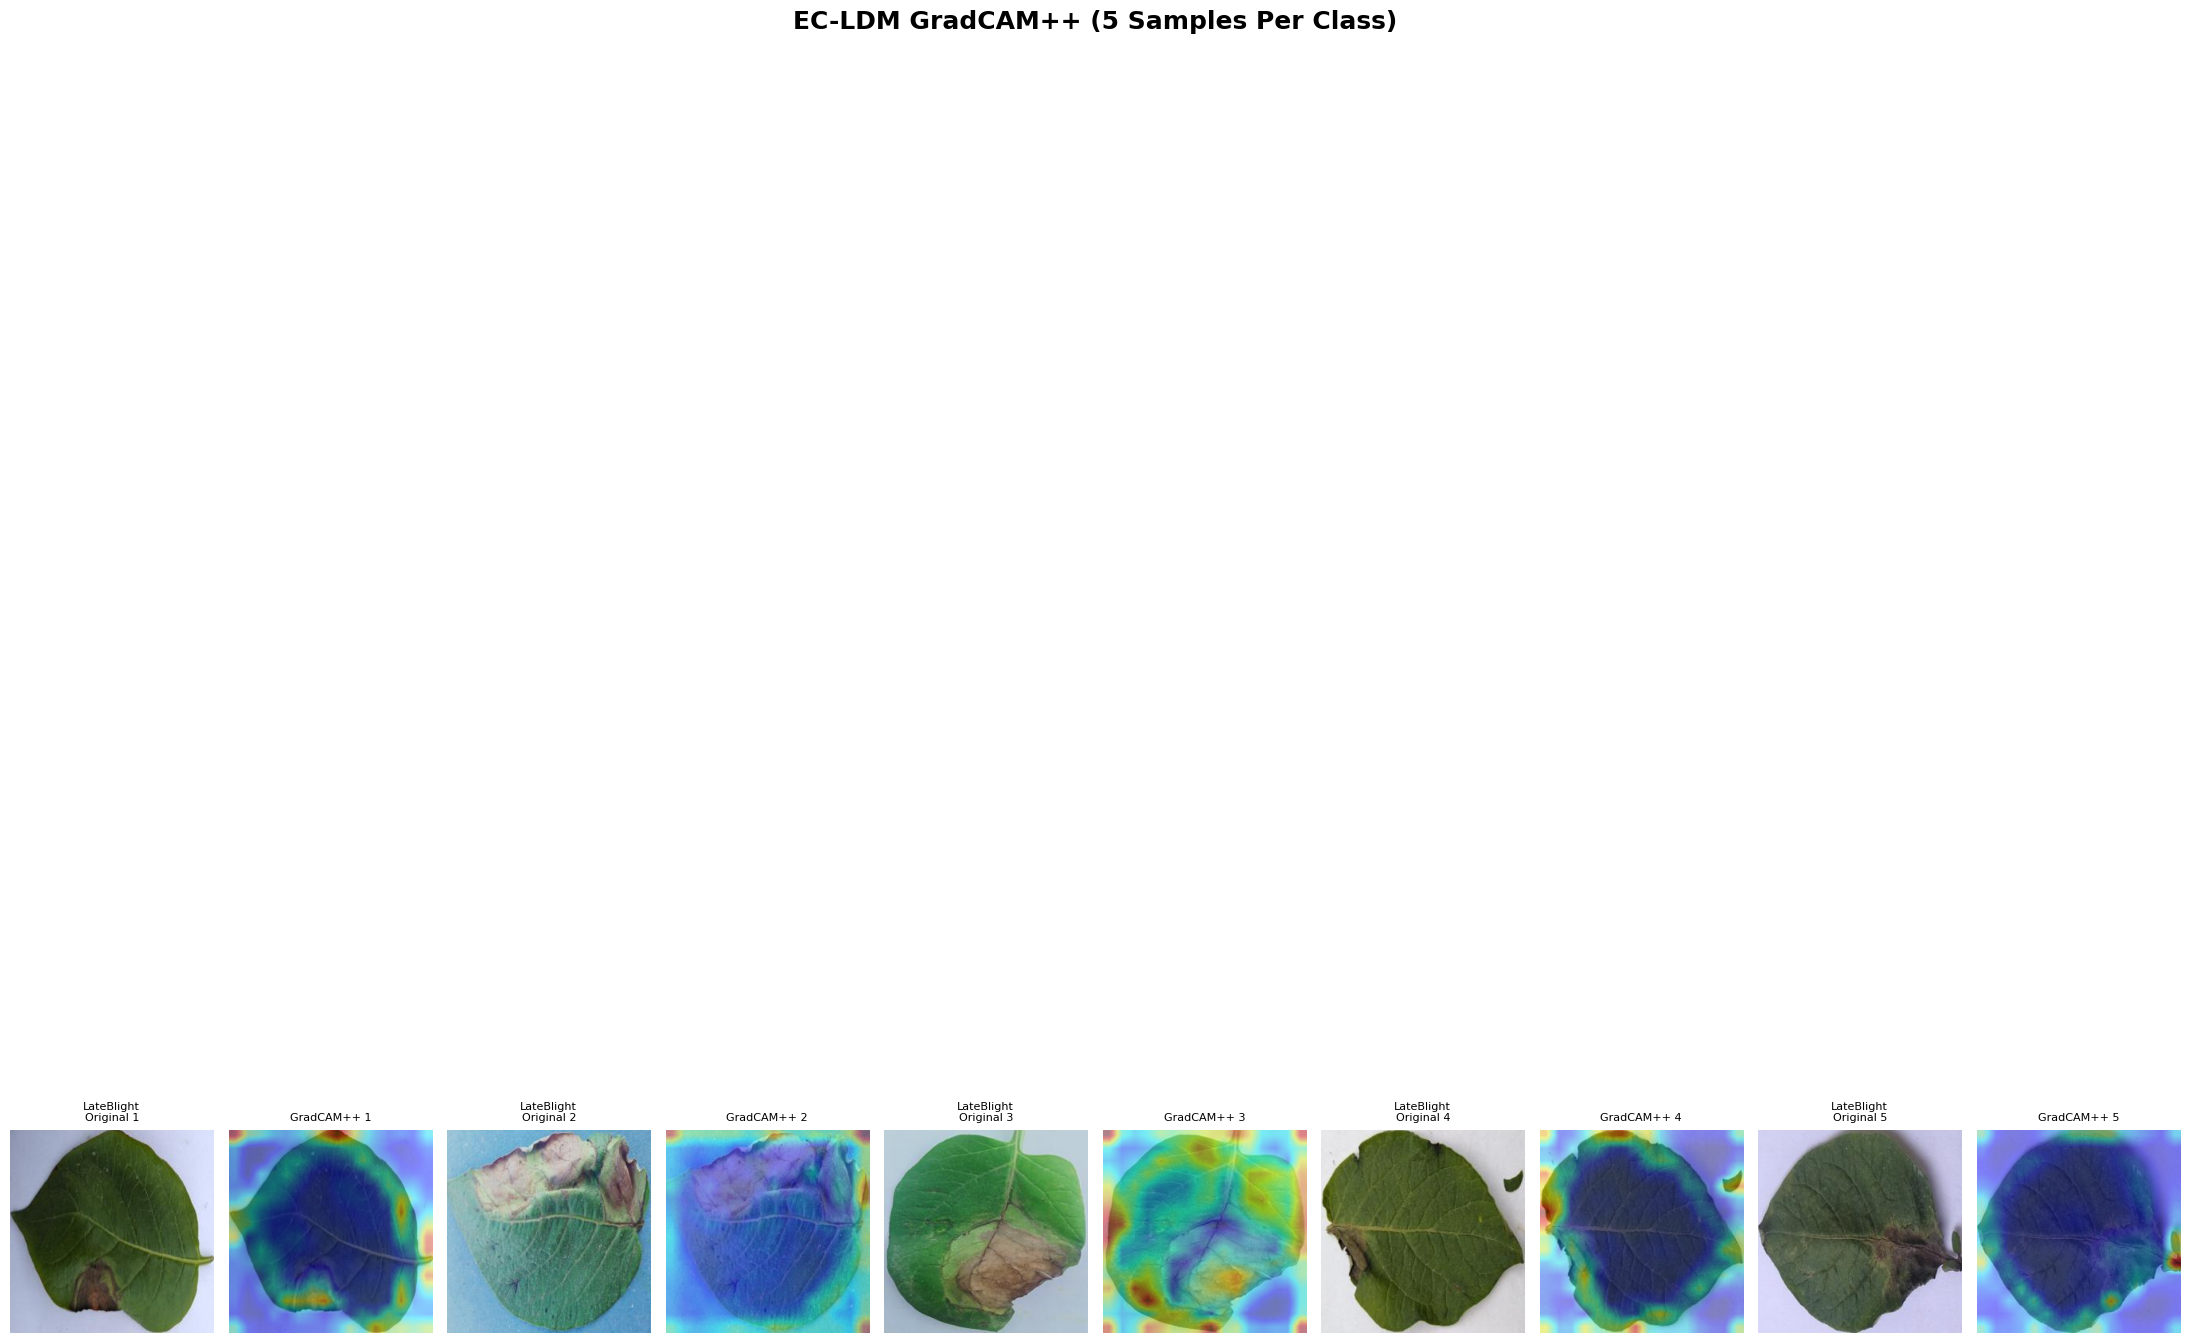


✅ GradCAM++ Visualization Completed


In [ ]:
# ============================================================
# EC-LDM GRADCAM++ VISUALIZATION
# 5 CORRECT SAMPLES PER CLASS
# ============================================================

!pip install grad-cam -q

import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ============================================================
# MODEL EVAL
# ============================================================

model.eval()

# ============================================================
# BEST LAYER FOR EC-LDM
# ============================================================

target_layers = [model.encoder.features[8]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

# ============================================================
# COLLECT SAMPLES
# ============================================================

NUM_SAMPLES = 5

samples = {
    i: []
    for i in range(len(dataset.classes))
}

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):

            true_class = labels[i].item()
            pred_class = preds[i].item()

            if true_class == pred_class:

                if len(samples[true_class]) < NUM_SAMPLES:

                    samples[true_class].append(
                        (
                            imgs[i].cpu(),
                            pred_class
                        )
                    )

        if all(
            len(samples[c]) >= NUM_SAMPLES
            for c in samples
        ):
            break

# ============================================================
# VERIFY COLLECTED SAMPLES
# ============================================================

print("\nCollected Samples:")

for class_id in samples:

    print(
        f"{dataset.classes[class_id]} -> "
        f"{len(samples[class_id])}"
    )

# ============================================================
# PLOT
# ============================================================

num_classes = len(dataset.classes)

fig, axes = plt.subplots(
    num_classes,
    NUM_SAMPLES * 2,
    figsize=(22, 5 * num_classes)
)

if num_classes == 1:
    axes = np.expand_dims(axes, axis=0)

for row, class_id in enumerate(samples.keys()):

    class_samples = samples[class_id]

    for idx in range(NUM_SAMPLES):

        col_orig = idx * 2
        col_cam = idx * 2 + 1

        # ----------------------------------------------------
        # EMPTY SLOT
        # ----------------------------------------------------

        if idx >= len(class_samples):

            axes[row, col_orig].axis("off")
            axes[row, col_cam].axis("off")
            continue

        img_tensor, pred_class = class_samples[idx]

        input_tensor = img_tensor.unsqueeze(0).to(device)

        targets = [
            ClassifierOutputTarget(pred_class)
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        # ----------------------------------------------------
        # DENORMALIZE
        # ----------------------------------------------------

        rgb_img = (
            img_tensor
            .permute(1, 2, 0)
            .numpy()
        )

        rgb_img = (rgb_img * 0.5) + 0.5

        rgb_img = np.clip(
            rgb_img,
            0,
            1
        )

        # ----------------------------------------------------
        # CAM OVERLAY
        # ----------------------------------------------------

        cam_image = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True,
            image_weight=0.6
        )

        # ----------------------------------------------------
        # ORIGINAL
        # ----------------------------------------------------

        axes[row, col_orig].imshow(rgb_img)

        axes[row, col_orig].set_title(
            f"{dataset.classes[class_id]}\nOriginal {idx+1}",
            fontsize=8
        )

        axes[row, col_orig].axis("off")

        # ----------------------------------------------------
        # GRADCAM++
        # ----------------------------------------------------

        axes[row, col_cam].imshow(cam_image)

        axes[row, col_cam].set_title(
            f"GradCAM++ {idx+1}",
            fontsize=8
        )

        axes[row, col_cam].axis("off")

plt.suptitle(
    "EC-LDM GradCAM++ (5 Samples Per Class)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print("\n✅ GradCAM++ Visualization Completed")

Feature Shape : (612, 1024)
Label Shape   : (612,)
t-SNE Shape : (612, 2)


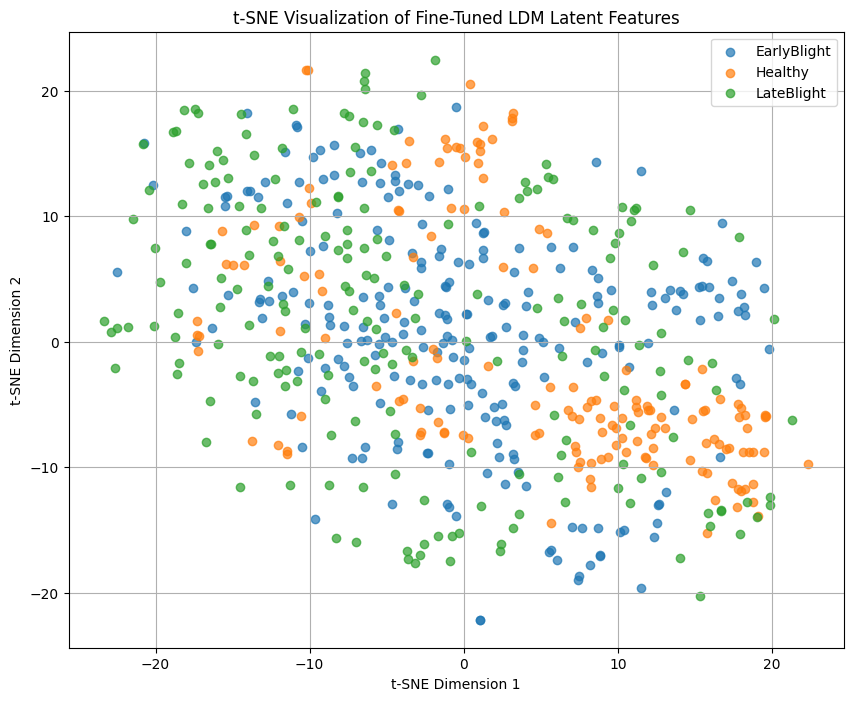


 t-SNE Visualization Completed


In [ ]:
# ============================================================
# t-SNE VISUALIZATION OF LDM LATENT FEATURES
# ============================================================

import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ============================================================
# EXTRACT LATENT FEATURES
# ============================================================

model.eval()

features = []
labels_list = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        # 512-D latent vector from encoder
        z = model.encoder(imgs)

        features.append(
            z.cpu().numpy()
        )

        labels_list.append(
            labels.numpy()
        )

features = np.concatenate(
    features,
    axis=0
)

labels_list = np.concatenate(
    labels_list,
    axis=0
)

print("Feature Shape :", features.shape)
print("Label Shape   :", labels_list.shape)

# ============================================================
# t-SNE
# ============================================================

tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate=200,

    init="pca",

    random_state=42

)

features_2d = tsne.fit_transform(
    features
)

print("t-SNE Shape :", features_2d.shape)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,8))

class_names = dataset.classes

for class_idx in range(len(class_names)):

    mask = labels_list == class_idx

    plt.scatter(

        features_2d[mask, 0],

        features_2d[mask, 1],

        label=class_names[class_idx],

        alpha=0.7

    )

plt.title(
    "t-SNE Visualization of Fine-Tuned LDM Latent Features"
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.legend()

plt.grid(True)

plt.show()

print("\n t-SNE Visualization Completed")

OVERALL PERFORMANCE
Accuracy  : 0.9951
Precision : 0.9951
Recall    : 0.9951
F1 Score  : 0.9951


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 EarlyBlight     0.9960    0.9920    0.9940       249
     Healthy     0.9866    1.0000    0.9932       147
  LateBlight     1.0000    0.9953    0.9977       214

    accuracy                         0.9951       610
   macro avg     0.9942    0.9958    0.9950       610
weighted avg     0.9951    0.9951    0.9951       610



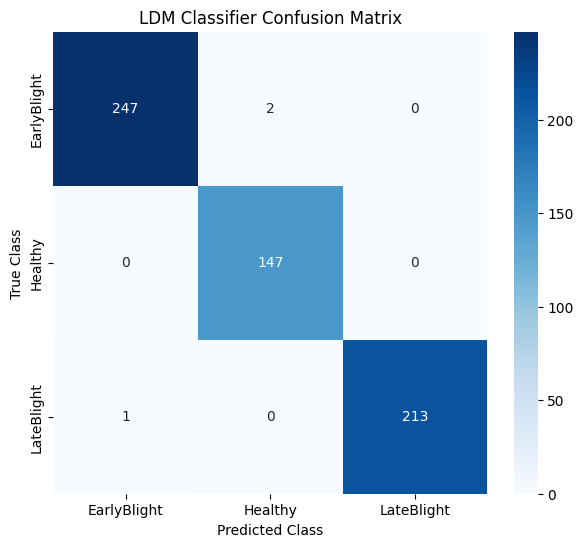

In [ ]:
# ============================================================
# CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------

acc = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("="*60)
print("OVERALL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=dataset.classes,

        digits=4

    )

)

# ------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=dataset.classes,

    yticklabels=dataset.classes

)

plt.title(
    "LDM Classifier Confusion Matrix"
)

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.show()